# 02 — Análise Exploratória dos Dados

Exploração da variável resposta e das variáveis explicativas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/dataset_vendedores.csv")
print(f"Dataset: {len(df):,} vendedores")

Dataset: 1,754 vendedores


## 1. Distribuição da variável resposta

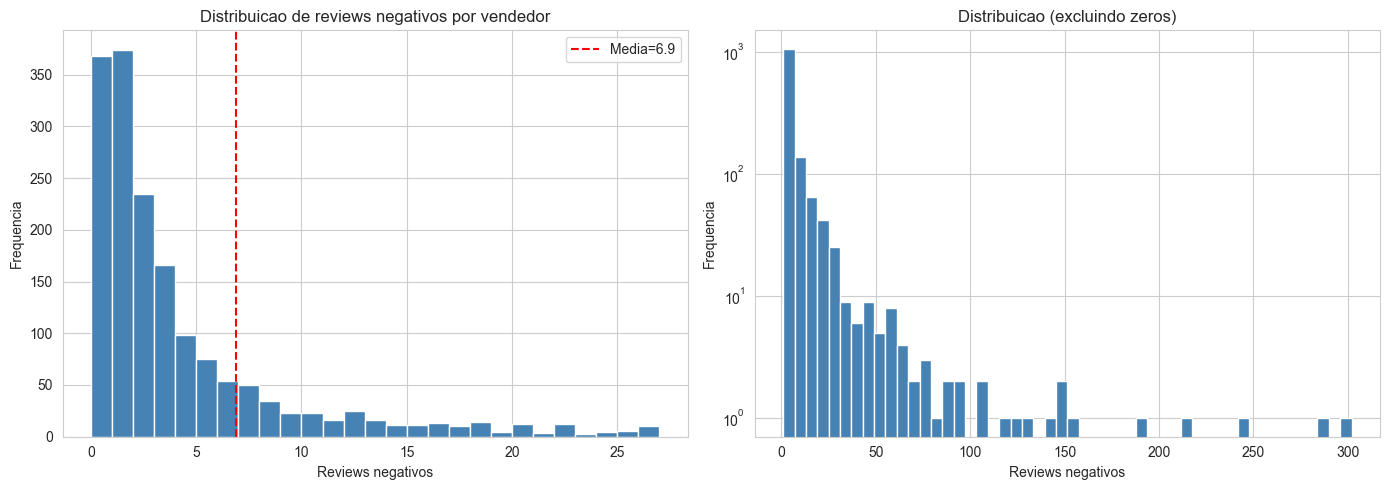

Media: 6.88, Variancia: 363.66, Var/Media: 52.90
Zeros: 368 (21.0%)


In [2]:
y = df["n_negative"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(y, bins=range(0, min(int(y.quantile(0.95))+2, 50)), color="steelblue", edgecolor="white")
axes[0].set_xlabel("Reviews negativos")
axes[0].set_ylabel("Frequencia")
axes[0].set_title("Distribuicao de reviews negativos por vendedor")
axes[0].axvline(y.mean(), color="red", linestyle="--", label=f"Media={y.mean():.1f}")
axes[0].legend()

# Log scale
axes[1].hist(y[y > 0], bins=50, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Reviews negativos")
axes[1].set_ylabel("Frequencia")
axes[1].set_title("Distribuicao (excluindo zeros)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("../outputs/eda_distribuicao_negativos.png", bbox_inches="tight")
plt.show()

print(f"Media: {y.mean():.2f}, Variancia: {y.var():.2f}, Var/Media: {y.var()/y.mean():.2f}")
print(f"Zeros: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")

## 2. Reviews negativos vs atraso de entrega

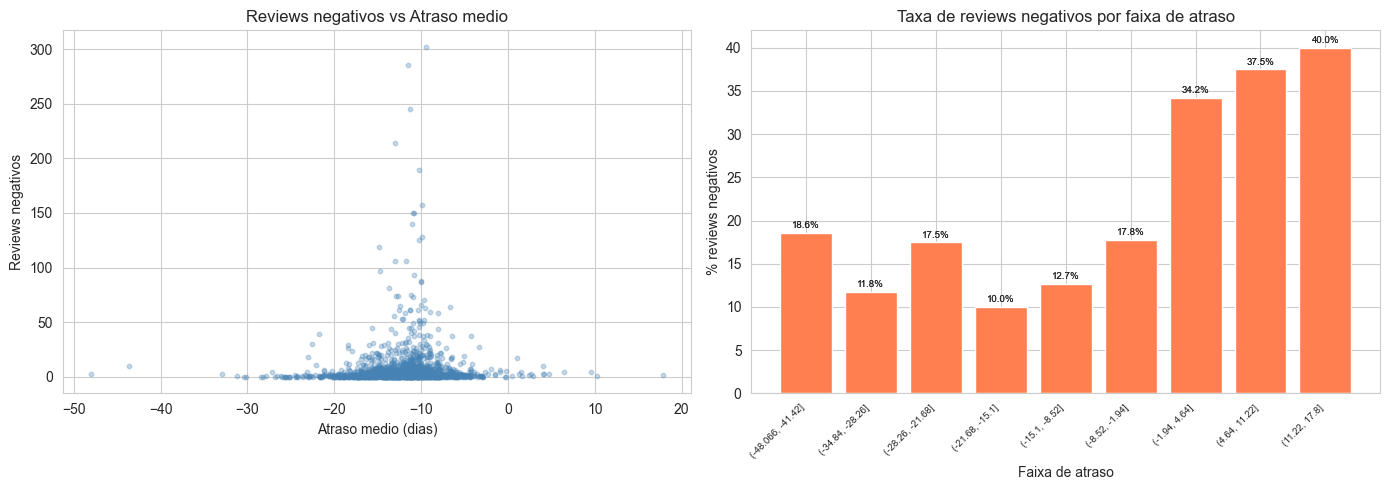

Correlacao n_negative vs atraso_medio: 0.051


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["atraso_medio"], df["n_negative"], alpha=0.3, s=10, color="steelblue")
axes[0].set_xlabel("Atraso medio (dias)")
axes[0].set_ylabel("Reviews negativos")
axes[0].set_title("Reviews negativos vs Atraso medio")

# Taxa de negativos vs atraso (binned)
df["atraso_bin"] = pd.cut(df["atraso_medio"], bins=10)
taxa = df.groupby("atraso_bin", observed=True).agg(
    taxa_neg=("n_negative", lambda x: x.sum()),
    n_reviews=("n_reviews", "sum")
).reset_index()
taxa["pct"] = taxa["taxa_neg"] / taxa["n_reviews"] * 100
axes[1].bar(range(len(taxa)), taxa["pct"], color="coral", edgecolor="white")
axes[1].set_xlabel("Faixa de atraso")
axes[1].set_ylabel("% reviews negativos")
axes[1].set_title("Taxa de reviews negativos por faixa de atraso")
axes[1].set_xticks(range(len(taxa)))
axes[1].set_xticklabels([str(x) for x in taxa["atraso_bin"]], rotation=45, ha="right", fontsize=7)
for j, v in enumerate(taxa["pct"]):
    axes[1].text(j, v + 0.3, f"{v:.1f}%", ha="center", va="bottom", fontsize=7)
for j, v in enumerate(taxa["pct"]):
    axes[1].text(j, v + 0.3, f"{v:.1f}%", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("../outputs/eda_negativos_vs_atraso.png", bbox_inches="tight")
plt.show()

print(f"Correlacao n_negative vs atraso_medio: {df['n_negative'].corr(df['atraso_medio']):.3f}")

## 3. Reviews negativos por categoria

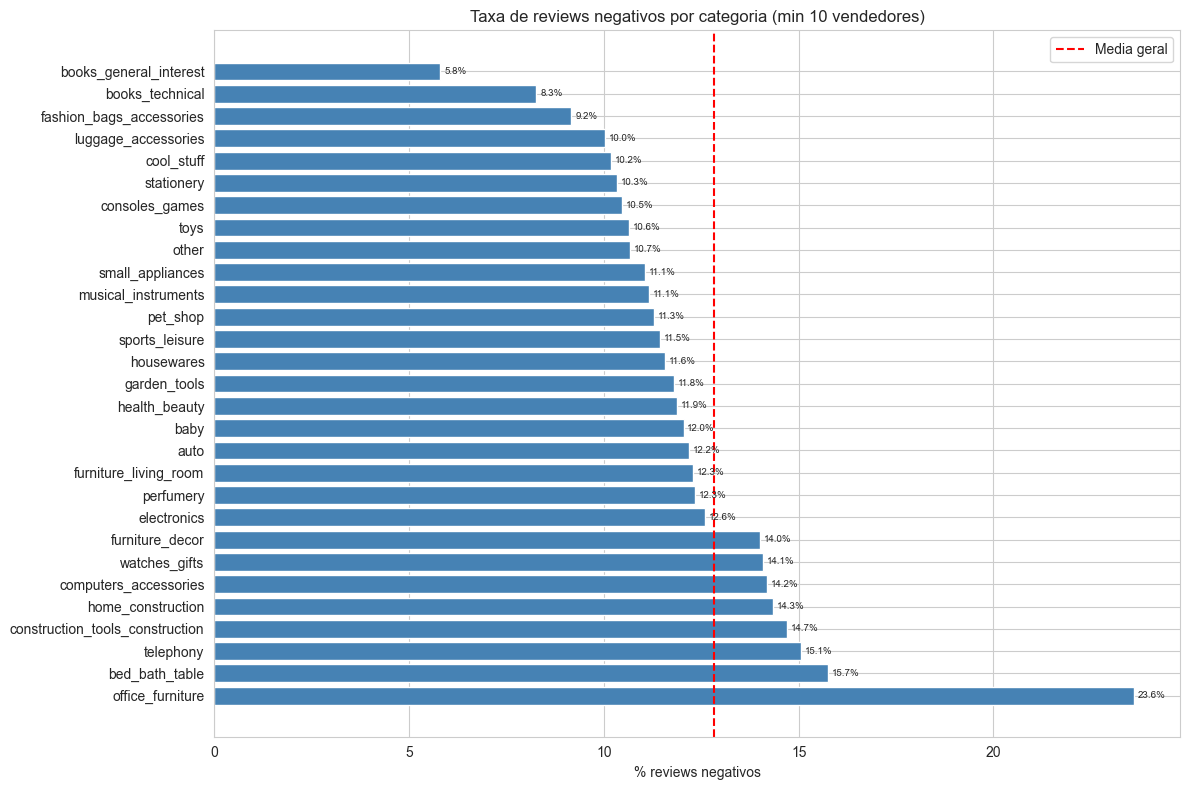

In [4]:
cat_stats = df.groupby("categoria_principal").agg(
    n_vendedores=("n_negative", "count"),
    neg_medio=("n_negative", "mean"),
    taxa_neg=("n_negative", lambda x: x.sum()),
    total_rev=("n_reviews", "sum")
).reset_index()
cat_stats["pct_neg"] = cat_stats["taxa_neg"] / cat_stats["total_rev"] * 100
cat_stats = cat_stats[cat_stats["n_vendedores"] >= 10].sort_values("pct_neg", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(cat_stats["categoria_principal"], cat_stats["pct_neg"], color="steelblue")
ax.set_xlabel("% reviews negativos")
ax.set_title("Taxa de reviews negativos por categoria (min 10 vendedores)")
ax.axvline(df["n_negative"].sum()/df["n_reviews"].sum()*100, color="red", linestyle="--", label="Media geral")
ax.legend()
for j, (val, label) in enumerate(zip(cat_stats["pct_neg"], cat_stats["categoria_principal"])):
    ax.text(val + 0.1, j, f"{val:.1f}%", va="center", fontsize=7)
plt.tight_layout()
plt.savefig("../outputs/eda_negativos_por_categoria.png", bbox_inches="tight")
plt.show()

## 4. Reviews negativos por estado

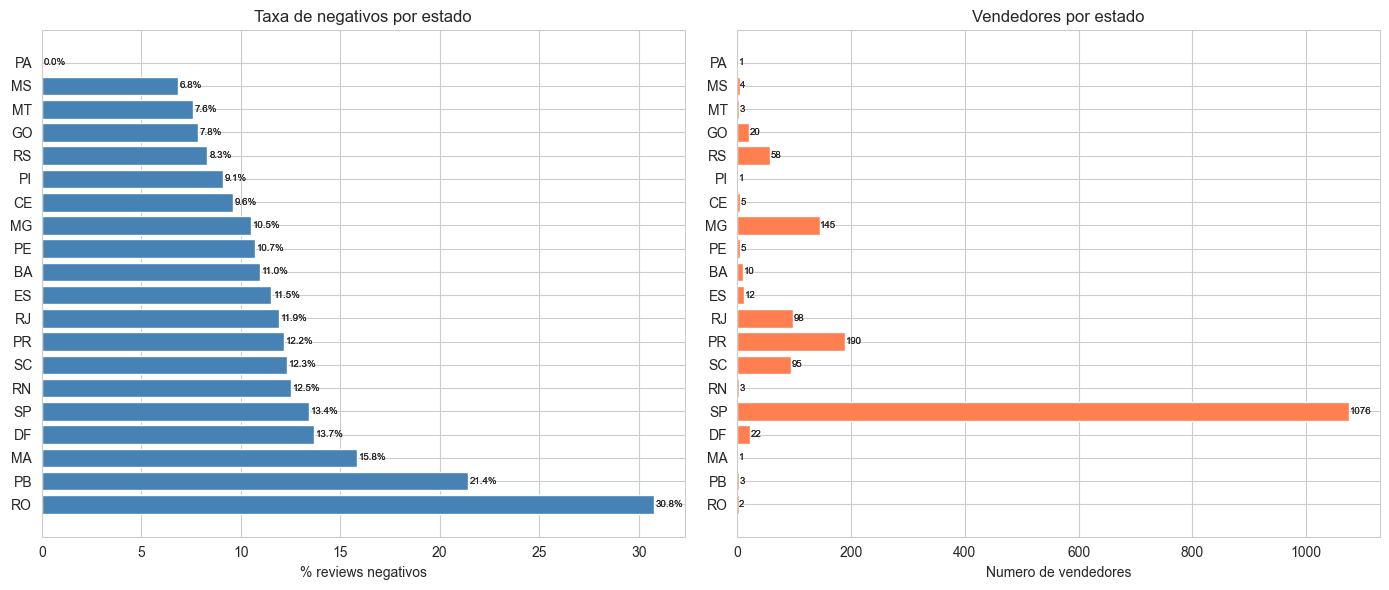

In [5]:
state_stats = df.groupby("seller_state").agg(
    n_vendedores=("n_negative", "count"),
    taxa_neg=("n_negative", "sum"),
    total_rev=("n_reviews", "sum")
).reset_index()
state_stats["pct_neg"] = state_stats["taxa_neg"] / state_stats["total_rev"] * 100
state_stats = state_stats.sort_values("pct_neg", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(state_stats["seller_state"], state_stats["pct_neg"], color="steelblue")
axes[0].set_xlabel("% reviews negativos")
axes[0].set_title("Taxa de negativos por estado")

axes[1].barh(state_stats["seller_state"], state_stats["n_vendedores"], color="coral")
axes[1].set_xlabel("Numero de vendedores")
axes[1].set_title("Vendedores por estado")

for j, (val, lbl) in enumerate(zip(state_stats["pct_neg"], state_stats["seller_state"])):
    axes[0].text(val + 0.1, j, f"{val:.1f}%", va="center", fontsize=7)
for j, (val, lbl) in enumerate(zip(state_stats["n_vendedores"], state_stats["seller_state"])):
    axes[1].text(val + 1, j, str(int(val)), va="center", fontsize=7)
for j, (val, lbl) in enumerate(zip(state_stats["pct_neg"], state_stats["seller_state"])):
    axes[0].text(val + 0.1, j, f"{val:.1f}%", va="center", fontsize=7)
for j, (val, lbl) in enumerate(zip(state_stats["n_vendedores"], state_stats["seller_state"])):
    axes[1].text(val + 1, j, str(int(val)), va="center", fontsize=7)
plt.tight_layout()
plt.savefig("../outputs/eda_negativos_por_estado.png", bbox_inches="tight")
plt.show()

## 5. Correlações entre variáveis contínuas

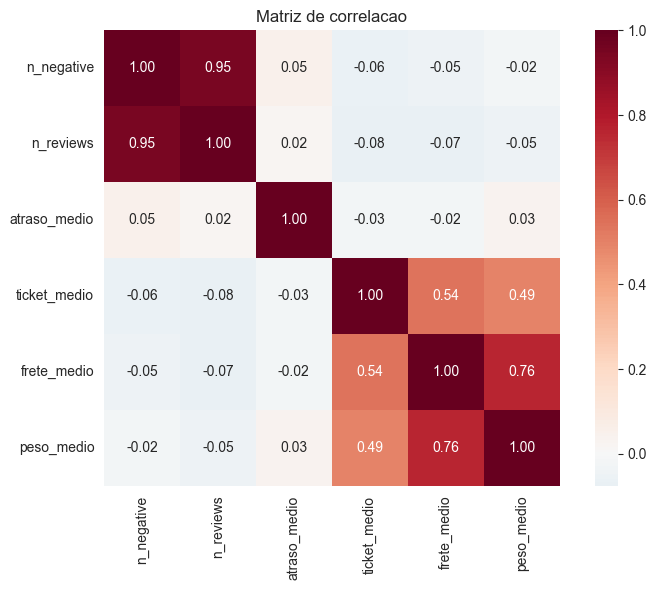

In [6]:
cont_vars = ["n_negative", "n_reviews", "atraso_medio", "ticket_medio", "frete_medio", "peso_medio"]
corr = df[cont_vars].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Matriz de correlacao")
plt.tight_layout()
plt.savefig("../outputs/eda_correlacao.png", bbox_inches="tight")
plt.show()

## 6. Sobredispersão — verificação preliminar

In [7]:
media = y.mean()
variancia = y.var()
razao = variancia / media

print("=== Verificacao de sobredispersao ===")
print(f"Media:     {media:.2f}")
print(f"Variancia: {variancia:.2f}")
print(f"Razao V/M: {razao:.2f}")
print()
if razao > 1:
    print(f"Razao V/M = {razao:.2f} >> 1 --> Sobredispersao forte")
    print("Poisson inadequado. Binomial Negativa necessaria.")

=== Verificacao de sobredispersao ===
Media:     6.88
Variancia: 363.66
Razao V/M: 52.90

Razao V/M = 52.90 >> 1 --> Sobredispersao forte
Poisson inadequado. Binomial Negativa necessaria.
